In [1]:
from run_simulation import run_simulation, print_statistics
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt

# Common parameters for both analyses
NUM_PERMITS = 6410
RANDOM_SEED = 42
INTER_ARRIVAL_TIME = 0.0  # run permits back-to-back


In [2]:
# Run all three simulations
print(f"Running sequential simulation with {NUM_PERMITS} permits...")
sim_sequential = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="sequential",
)

print(f"\nRunning standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
)

print(f"\nRunning parallel simulation with {NUM_PERMITS} permits...")
sim_parallel = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="parallel",
)

Running sequential simulation with 6410 permits...

Running standard simulation with 6410 permits...

Running parallel simulation with 6410 permits...


In [3]:
# Print statistics for each process
print("=== SEQUENTIAL PROCESS ===")
stats_sequential = sim_sequential.get_statistics()
print_statistics(stats_sequential)

print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("\n=== PARALLEL PROCESS ===")
stats_parallel = sim_parallel.get_statistics()
print_statistics(stats_parallel)


=== SEQUENTIAL PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4630 (72.23%)
  CUSTOM_NON_LIKE               : 1148 (17.91%)
  PRE_APPROVED_LIKE             :   93 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.33%)
  SELF_CERT_LIKE                :  425 ( 6.63%)
  SELF_CERT_NON_LIKE            :   93 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     435.47 days
  Median:   417.58 days
  Std Dev:  136.33 days
  Min:      152.69 days
  Max:     2520.10 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT

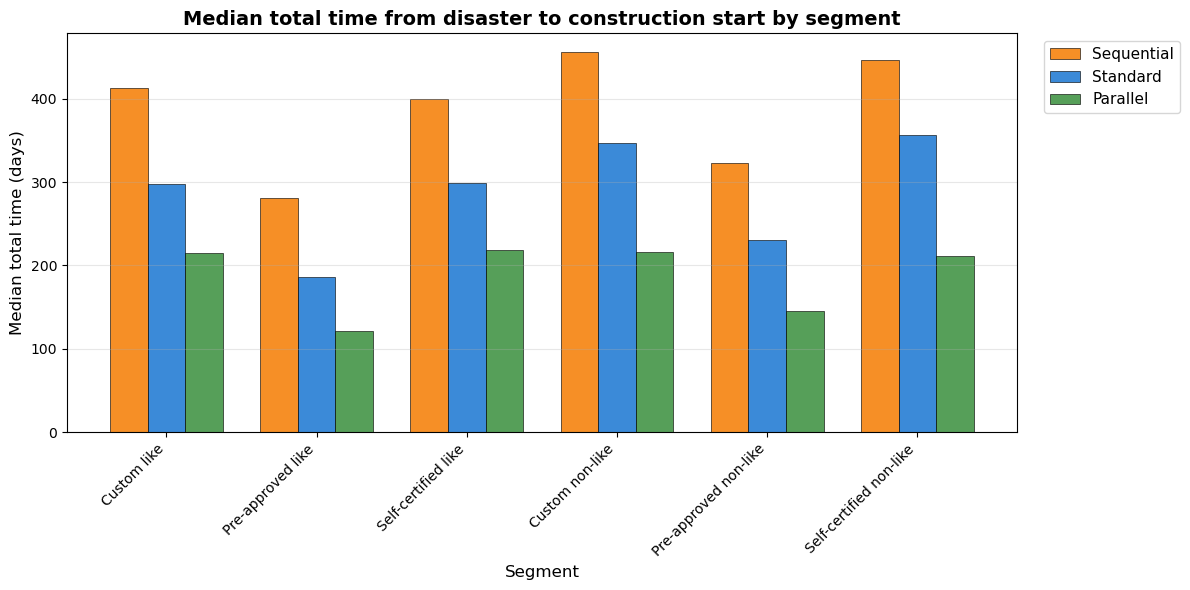

In [4]:
# Compare median total time (disaster to construction) by segment
permits_by_process = {
    "Sequential": sim_sequential.completed_permits,
    "Standard": sim_standard.completed_permits,
    "Parallel": sim_parallel.completed_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()


SEQUENTIAL process – Segment 4 permit


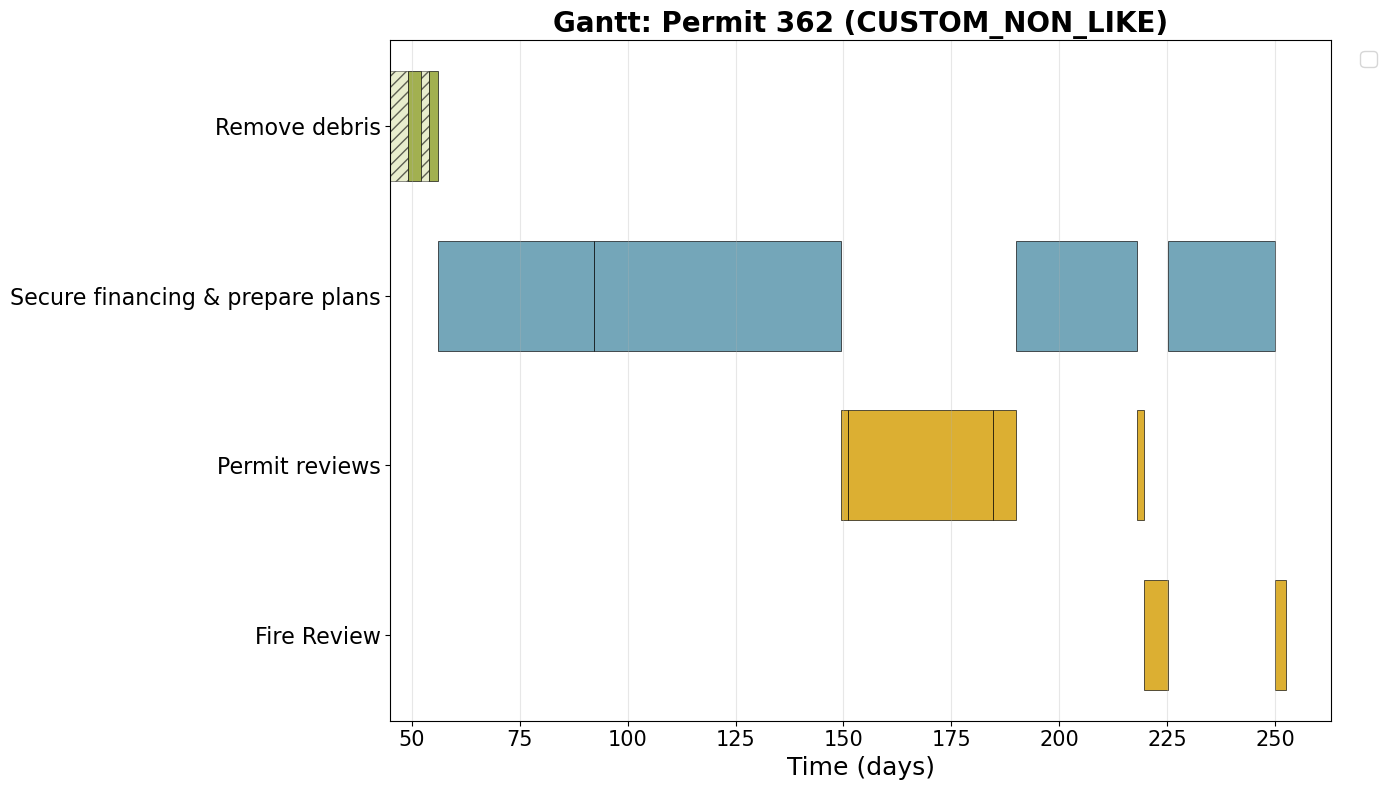


STANDARD process – Segment 4 permit


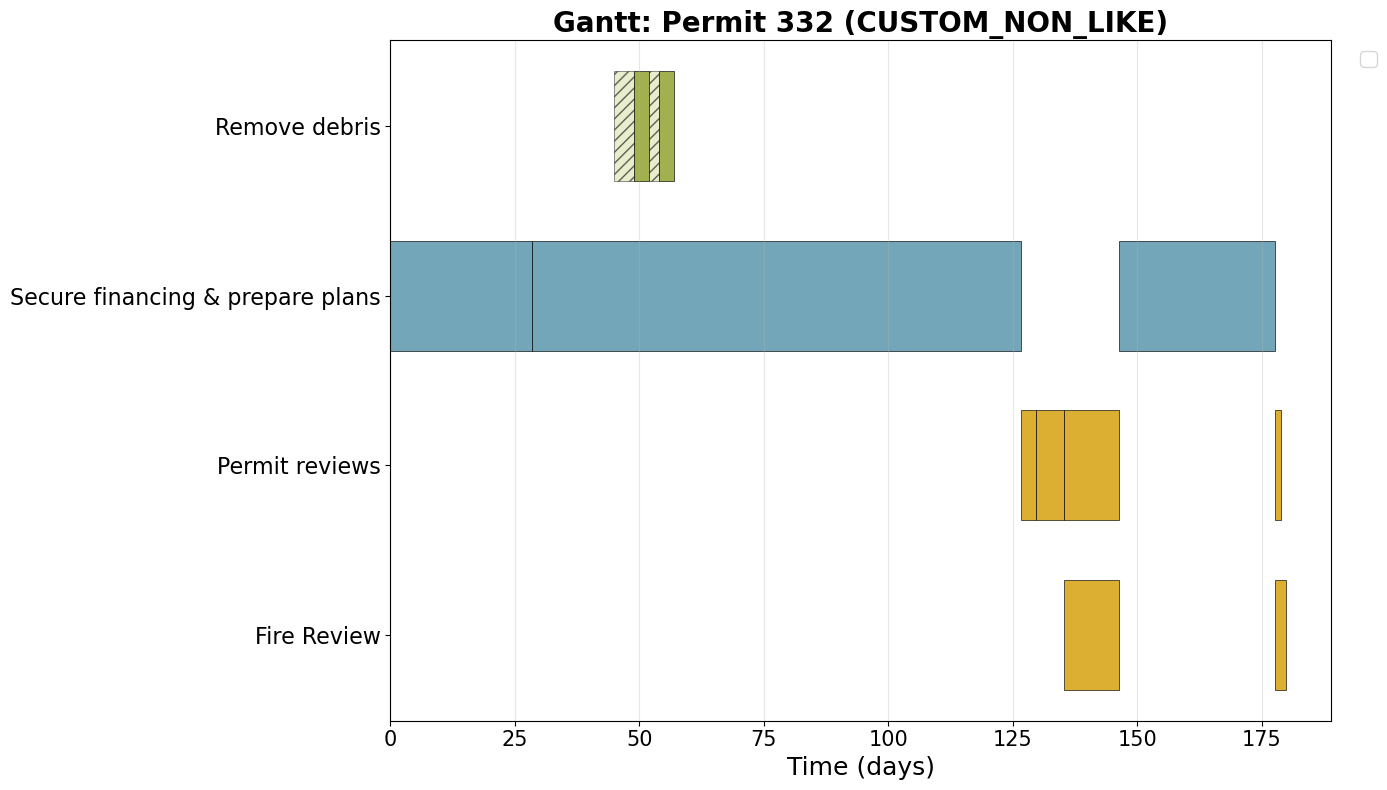


PARALLEL process – Segment 4 permit


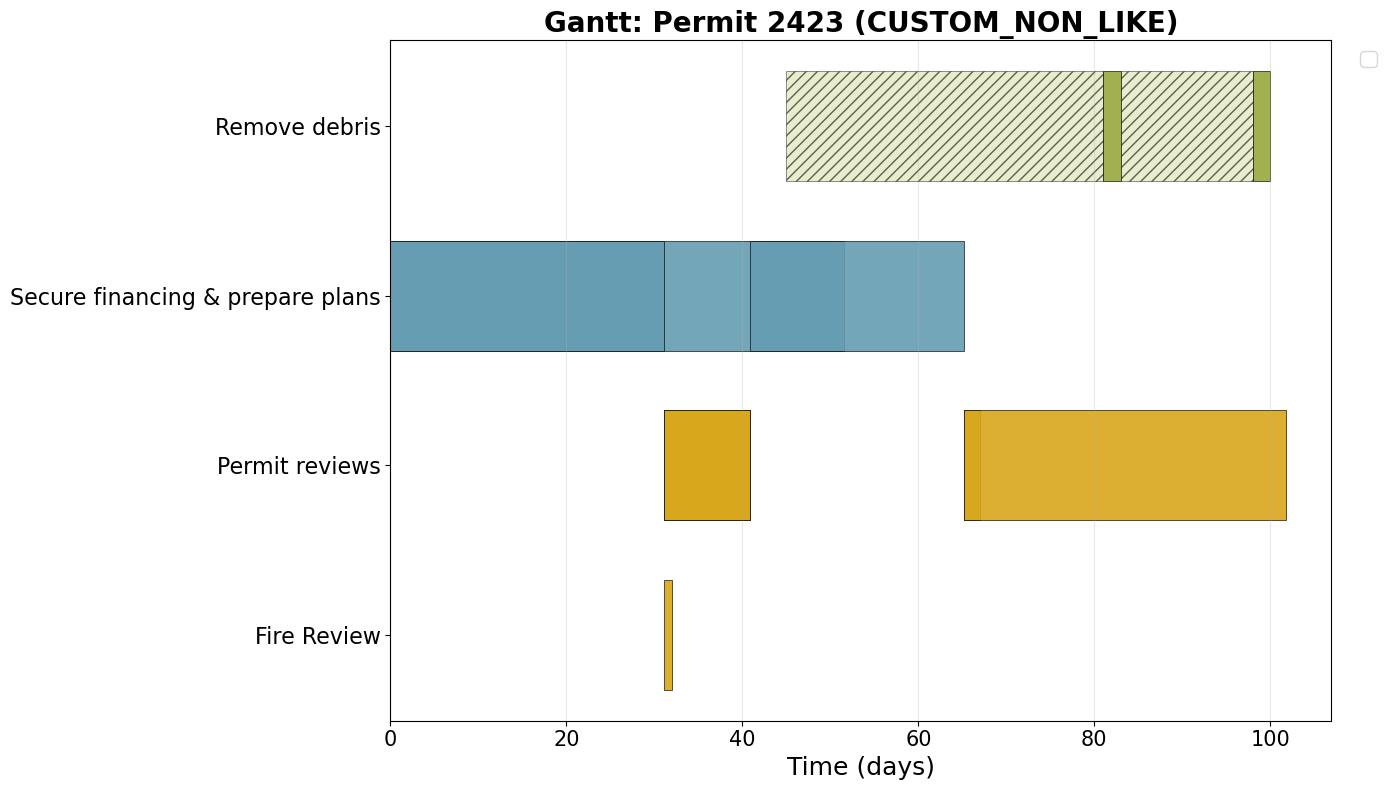

In [5]:
# Gantt charts for one random Segment 4 permit under each process
print("SEQUENTIAL process – Segment 4 permit")
fig1, ax1 = plot_gantt_one_random_permit_segment(
    sim_sequential.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig1 is not None:
    plt.show()

print("\nSTANDARD process – Segment 4 permit")
fig2, ax2 = plot_gantt_one_random_permit_segment(
    sim_standard.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig2 is not None:
    plt.show()

print("\nPARALLEL process – Segment 4 permit")
fig3, ax3 = plot_gantt_one_random_permit_segment(
    sim_parallel.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig3 is not None:
    plt.show()


Creating visualizations for SEQUENTIAL process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


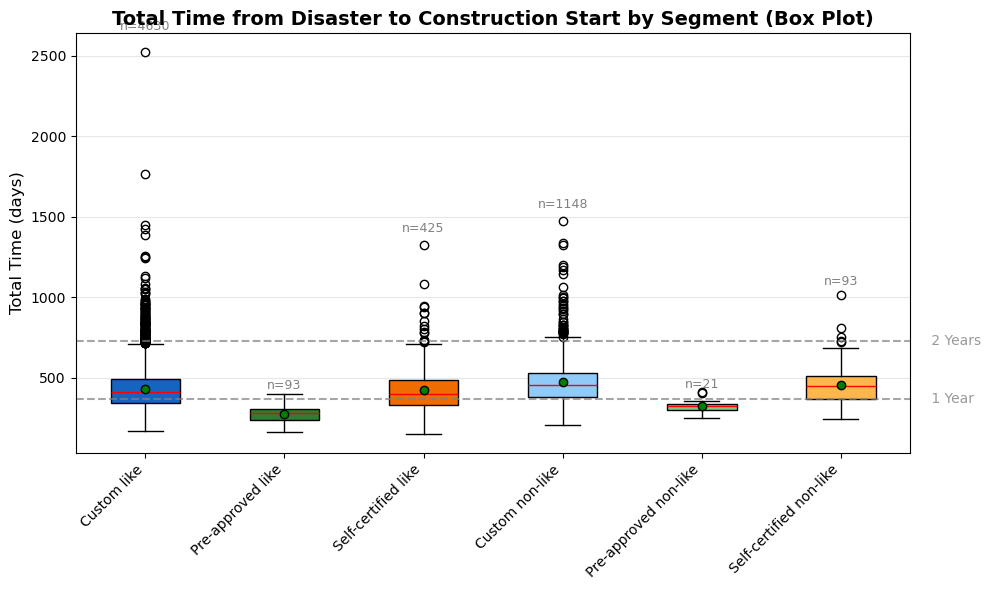

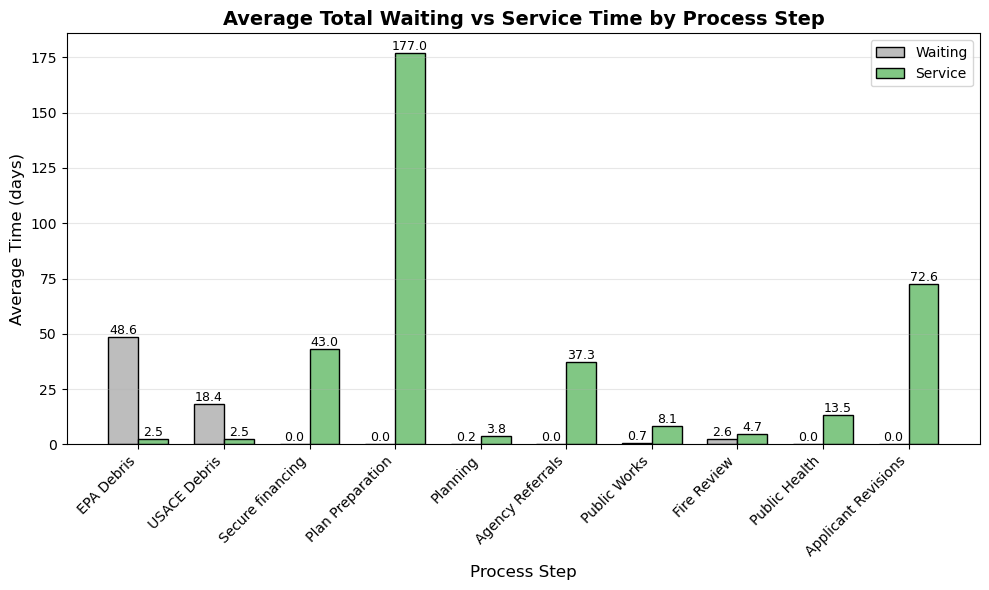

Visualizations complete!


In [6]:
# Full visualization set for each process (mirrors prior single-process notebooks)
print("Creating visualizations for SEQUENTIAL process...")
visualize_all(sim_sequential.completed_permits, save_prefix=None, show=True)



Creating visualizations for STANDARD process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


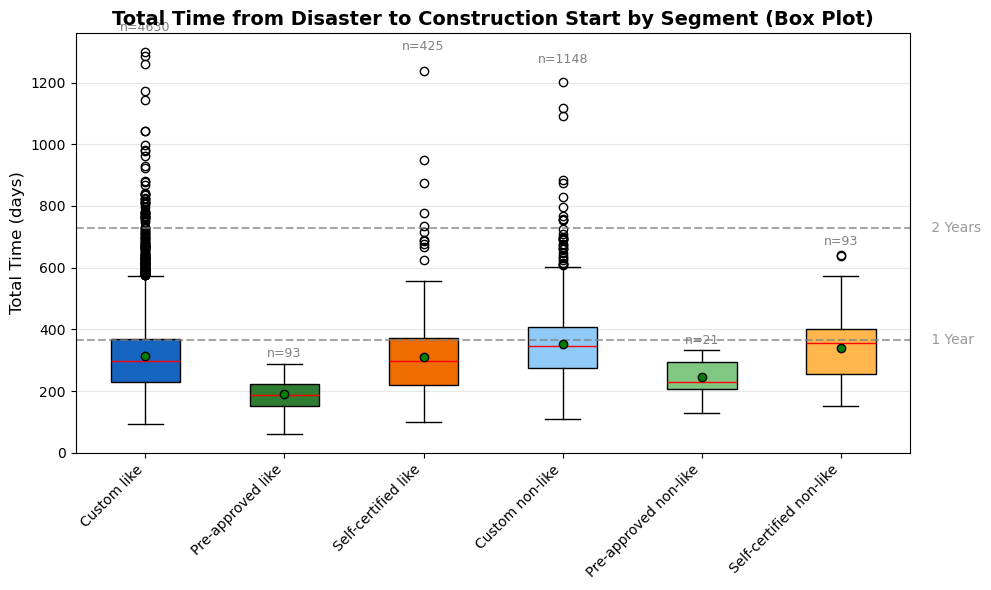

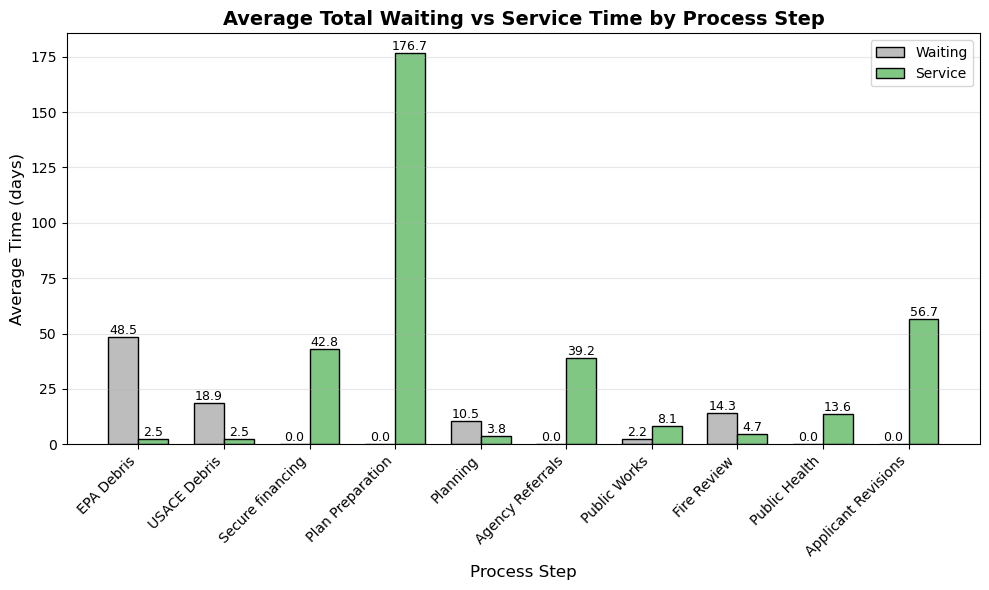

Visualizations complete!


In [7]:
print("\nCreating visualizations for STANDARD process...")
visualize_all(sim_standard.completed_permits, save_prefix=None, show=True)


Creating visualizations for SEQUENTIAL process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


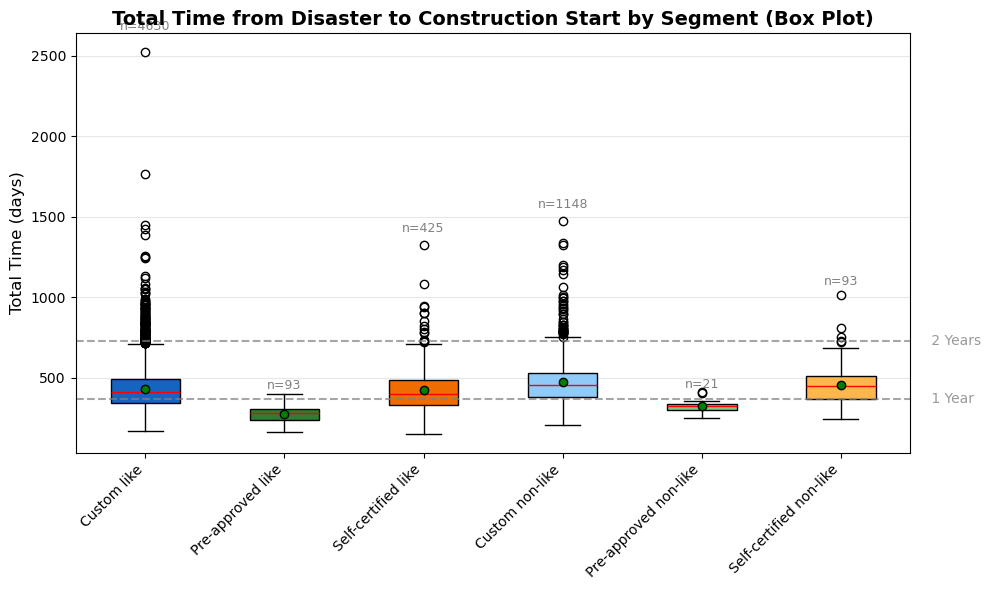

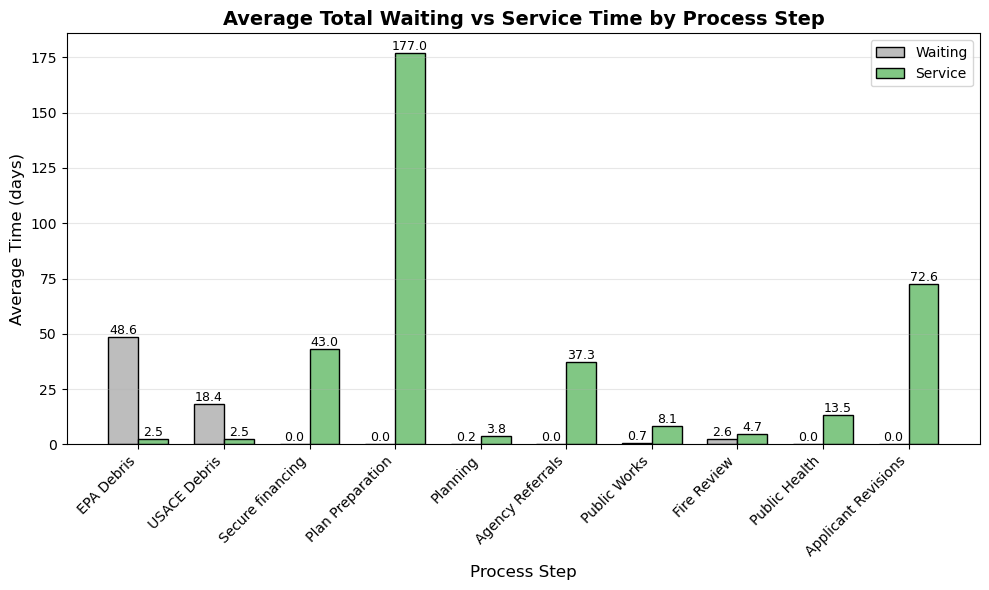

Visualizations complete!


In [8]:
print("\nCreating visualizations for SEQUENTIAL process...")
visualize_all(sim_sequential.completed_permits, save_prefix=None, show=True)